In [5]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
from pathlib import Path

In [6]:
conn = sqlite3.connect("../data/db/bluestock_mf.db")

performance = pd.read_sql(
    "SELECT * FROM fact_performance",
    conn
)

transactions = pd.read_sql(
    "SELECT * FROM fact_transactions",
    conn
)

holdings = pd.read_sql(
    "SELECT * FROM fact_portfolio_holdings",
    conn
)

nav = pd.read_sql(
    "SELECT * FROM fact_nav",
    conn
)

fund_master = pd.read_sql(
    "SELECT * FROM fact_fund_master",
    conn
)

conn.close()

In [7]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

results = []

for code, grp in nav.groupby("amfi_code"):

    returns = grp["daily_return"].dropna()

    if len(returns) < 30:
        continue

    var95 = np.percentile(
        returns,
        5
    )

    cvar95 = returns[
        returns <= var95
    ].mean()

    results.append([
        code,
        var95,
        cvar95
    ])

var_df = pd.DataFrame(
    results,
    columns=[
        "amfi_code",
        "var_95",
        "cvar_95"
    ]
)

var_df.to_csv(
    "../reports/During_Internship/Day-06/var_cvar_report.csv",
    index=False
)

In [8]:
top5 = (
    performance
    .sort_values(
        "aum_crore",
        ascending=False
    )
    .head(5)
)

codes = top5["amfi_code"]

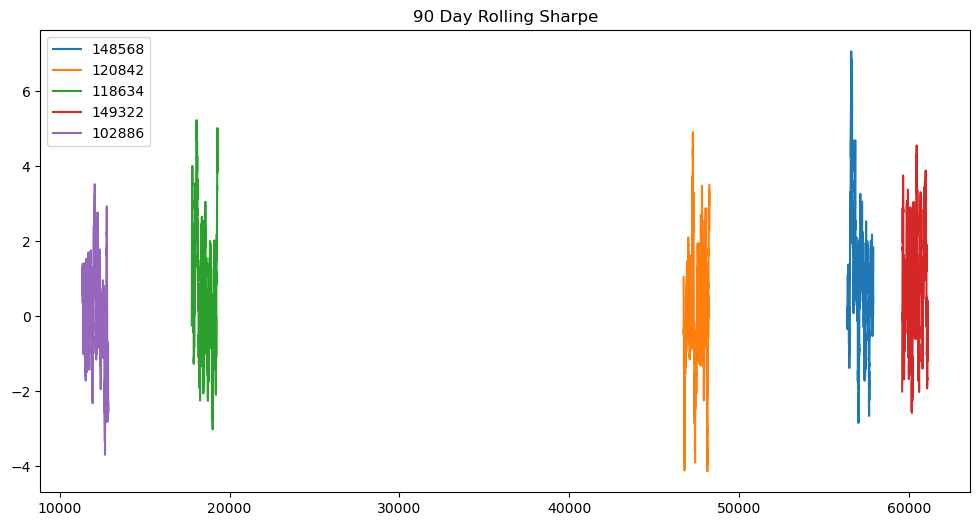

In [9]:
plt.figure(figsize=(12,6))

for code in codes:

    temp = nav[
        nav["amfi_code"] == code
    ].copy()

    temp["return"] = (
        temp["nav"].pct_change()
    )

    temp["rolling_sharpe"] = (
        temp["return"]
        .rolling(90)
        .mean()
        /
        temp["return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        temp.index,
        temp["rolling_sharpe"],
        label=code
    )

plt.legend()
plt.title("90 Day Rolling Sharpe")

plt.savefig(
    "../reports/During_Internship/Day-06/rolling_sharpe_chart.png"
)

plt.show()

In [10]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

cohort = (
    transactions.groupby("investor_id")
    ["transaction_date"]
    .min()
)

transactions["cohort_year"] = (
    transactions["investor_id"]
    .map(cohort.dt.year)
)

In [11]:
cohort_analysis = (
    transactions
    .groupby("cohort_year")
    .agg(
        avg_amount=(
            "amount_inr",
            "mean"
        ),
        total_invested=(
            "amount_inr",
            "sum"
        )
    )
)

cohort_analysis.to_csv(
    "../reports/During_Internship/Day-06/cohort_analysis.csv"
)

In [12]:
sip = transactions[
    transactions["transaction_type"]
    == "SIP"
]

In [13]:
sip = sip.sort_values(
    [
        "investor_id",
        "transaction_date"
    ]
)

sip["gap"] = (
    sip.groupby("investor_id")
    ["transaction_date"]
    .diff()
    .dt.days
)

continuity = (
    sip.groupby("investor_id")
    .agg(
        avg_gap=("gap","mean"),
        sip_count=("gap","count")
    )
)

continuity = continuity[
    continuity["sip_count"] >= 6
]

continuity["at_risk"] = (
    continuity["avg_gap"] > 35
)

continuity.to_csv(
    "../reports/During_Internship/Day-06/sip_continuity.csv"
)

In [16]:
import pandas as pd
import sqlite3

conn = sqlite3.connect(
    "../data/db/bluestock_mf.db"
)

df = pd.read_sql(
    "SELECT * FROM fact_performance",
    conn
)

risk = input(
    "Risk Appetite (Low/Moderate/High): "
)

recommend = (
    df[
        df["risk_grade"]
        .str.contains(
            risk,
            case=False,
            na=False
        )
    ]
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .head(3)
)

print(recommend[
    [
        "scheme_name",
        "sharpe_ratio",
        "alpha",
        "risk_grade"
    ]
])

                                 scheme_name  sharpe_ratio  alpha risk_grade
14  ICICI Pru Liquid Fund - Regular - Growth          7.68   1.85        Low
23      Kotak Liquid Fund - Regular - Growth          6.18   1.52        Low
30       ABSL Liquid Fund - Regular - Growth          5.14   1.18        Low


In [17]:
hhi = (
    holdings.groupby(
        "amfi_code"
    )["weight_pct"]
    .apply(
        lambda x:
        ((x/100)**2).sum()
    )
    .reset_index()
)

hhi.columns = [
    "amfi_code",
    "HHI"
]

hhi.to_csv(
    "../reports/During_Internship/Day-06/sector_hhi.csv",
    index=False
)

In [18]:
performance["risk_grade"].unique()

array(['Moderate', 'Very High', 'Low', 'High', 'Moderately High'],
      dtype=object)

## Fund Recommendation Engine

A rule-based recommendation engine was developed to suggest funds based on investor risk appetite.

Risk Mapping:
- Low → Low Risk Funds
- Moderate → Moderate + Moderately High Risk Funds
- High → High + Very High Risk Funds

Recommendation Score:

35% Sharpe Ratio
25% Sortino Ratio
20% Alpha
20% 3-Year Return

The top 3 funds with the highest composite score are recommended to the investor.